# 실행 환경 확인 및 커널 선택 안내
- 커널을 상단 오른쪽에서 "Python 3.12 (DX venv)"로 선택해 주세요.
- 아래 셀을 실행해 현재 파이썬 경로와 gensim 설치 여부를 확인합니다.


In [1]:
import sys
print(sys.executable)
try:
    import gensim, numpy, scipy
    print("OK", gensim.__version__)
except Exception as e:
    print("Import error:", repr(e))


c:\Python312\python.exe
OK 4.3.3
OK 4.3.3


<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx08.png" width=100%>  
</center>
 

In [2]:
import pandas as pd


In [3]:
import numpy as np

# 1.군집 데이터 불러오기

In [4]:
# Actor실습에서 군집 번호 맵핑까지 해둔 데이터 프레임
import pickle
import pandas as pd

df = pd.read_pickle("./data/cluster_df.pkl")
df.head()

,review,review_clean,tagged_review,vector,cluster
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,"[주휴수당, 관련, 문의, 댓글, 더, 답변, 드리다, 영상, 시청, 주다, 감사하...","[-0.015925527, -0.030626636, -0.015063466, 0.0...",0
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,"[근로, 일수, 체우, 지각, 조퇴, 상관없다, 건가, 근로계약서, 지키다, 지키다...","[-0.014826028, -0.010363224, -0.002446767, 0.0...",0
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,"[주, 근로, 주, 근로, 소리, 알다, 드덱, 어요, 궁금하다, 주, 주, 시급,...","[-0.06059343, -0.045346346, 0.014628361, 0.034...",0
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,"[선생님, 주, 하루, 바쁘다, 더하다, 경우, 잔업, 해당, 되어다, 배, 주다,...","[-0.019944737, -0.018242465, 0.002956187, 0.04...",0
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,"[미치다, 치킨, 받다, 부당하다, 당하다, 검색, 왕, 노무사, 영상, 접, 답답...","[-0.099948436, -0.032038588, 0.021273611, 0.00...",0


## LDA(Latent Dirichlet Allocation)
- 토픽 모델링 : 문서의 집합으로부터 어떤 토픽이 존재하는지를 알아내기 위한 알고리즘
- 잠재 디리클레 할당(LDA): 토픽 모델링의 대표적인 알고리즘
    - 주어진 문서에 대해 각 문서에 어떤 주제들이 존재하는지에 대한 확률모형
    - 토픽별 단어의 분포, 문서별 토픽의 분포를 모두 추정

<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx07.png" width=50%>  
</center>
 

- LDA는 특정 토픽에 특정 단어가 나타날 확률을 추정
    - 노란색 토픽엔 gene이라는 단어가 등장할 확률이 0.04, DNA는 0.02, Genetic은 0.01 이므로 노란색 토픽은 대략 유전자 관련 주제로 추정
    - 주어진 문서를 보면 파란색, 빨간색 토픽에 해당하는 단어보다는 노란색 토픽에 해당하는 단어들이 많으므로 문서의 메인 주제는 유전자 관련일 가능성이 큼

- 문서 생성 과정
    - 우선 말뭉치로부터 얻은 토픽 분포에서 토픽을 추출
    - 해당 토픽에 해당하는 단어들을 추출하여 문서를 생성

- 현재 문서에 등장한 단어들은 어떤 토픽에서 뽑힌 단어들인지 명시적으로 알기 어려움=> 말뭉치 이면에 존재하는 잠재(Latent) 정보를 추론하는 LDA

### LDA 프로세스
1. 토픽 개수 k 설정
- 사용자가 LDA에 미리 토픽 개수(k)를 선정
2. 초기 토픽 할당
- 모든 문서의 각 단어에 대해, k개의 토픽 중 랜덤으로 하나를 할당
- 결과: 각 문서는 여러 토픽에 속하며, 각 토픽은 단어 분포를 갖게 됨
3. 토픽 재할당 반복
- 목표: 잘못 할당된 단어를 올바른 토픽으로 재분류하여, 문서와 토픽의 분포를 개선
- 가정: 문서 d의 단어 w는 현재 잘못된 토픽에 할당되어 있을 수 있으나, 나머지 단어들은 올바르게 할당되어 있다고 봄
- 재할당 기준(principle): 
    - 문서 내 기준: 문서 d내에서 토픽 t에 속한 단어들의 비율
    - 전체 문서 기준: 전체 문서에서 토픽 t가 단어 w를 얼마나 잘 설명하는지(w의 분포)
    - 이 두 기준을 종합하여 단어 w의 토픽 할당을 반복적으로 재조정

**토픽 재할당 예시**
  - **상황** : 두 개의 문서(`doc1`,`doc2`)가 있고, `doc1`의 세번째 단어 `apple`의 토픽을 결정하고자 함
 
  - **(a) 초기 상황:**  
    - "apple"은 아직 초기 랜덤 할당 상태  
    <center>
      <img src="https://wikidocs.net/images/page/30708/lda1.PNG" width="50%" alt="초기 할당 예시">
    </center>
 
  - **(b) 첫 번째 기준 (문서 내 단어 분포):**  
    - `doc1`의 모든 단어가 토픽 A와 토픽 B에 5:5 비율로 할당되어 있다면, "apple"은 두 토픽 모두에 속할 가능성이 있음  
    <center>
      <img src="https://wikidocs.net/images/page/30708/lda3.PNG" width="50%" alt="문서 내 단어 분포">
    </center>
 
  - **(c) 두 번째 기준 (전체 문서 단어 분포):**  
    - 전체 문서에서 "apple"의 분포를 보면 토픽 B에 더 많이 할당되어 있음  
    <center>
      <img src="https://wikidocs.net/images/page/30708/lda2.PNG" width="50%" alt="전체 문서 단어 분포">
    </center>
 
- **최종 결정:**  
  - 두 기준을 종합해 LDA는 `doc1`의 "apple"을 **토픽 B**에 할당
 
 

## 1. LDA를 위한 데이터 전처리
- 정수 인코딩(수치화)과 단어 사전 생성
> 단어들이 문서에 얼마나 위치해 있는지 분포를 파악해야하기 때문에 분석할 전체 데이터 대상으로 사용된 단어사전을 생성


- 단어들에 고유 ID 부여 후, BOW(Back of Words) 표현
    - BOW란? 문서 내에서 단어의 출현 여부만을 고려한 표현 방식으로, 각 단어의 빈도 수를 기반으로 문서를 벡터화하는 방법

In [5]:
# 0번 클러스터 문서 접근 -> 0번째 문서로만 확인
cluster = 0
df_cluster0 = df[df["cluster"] == cluster]
df_cluster0.head()

,review,review_clean,tagged_review,vector,cluster
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,"[주휴수당, 관련, 문의, 댓글, 더, 답변, 드리다, 영상, 시청, 주다, 감사하...","[-0.015925527, -0.030626636, -0.015063466, 0.0...",0
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,"[근로, 일수, 체우, 지각, 조퇴, 상관없다, 건가, 근로계약서, 지키다, 지키다...","[-0.014826028, -0.010363224, -0.002446767, 0.0...",0
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,"[주, 근로, 주, 근로, 소리, 알다, 드덱, 어요, 궁금하다, 주, 주, 시급,...","[-0.06059343, -0.045346346, 0.014628361, 0.034...",0
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,"[선생님, 주, 하루, 바쁘다, 더하다, 경우, 잔업, 해당, 되어다, 배, 주다,...","[-0.019944737, -0.018242465, 0.002956187, 0.04...",0
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,"[미치다, 치킨, 받다, 부당하다, 당하다, 검색, 왕, 노무사, 영상, 접, 답답...","[-0.099948436, -0.032038588, 0.021273611, 0.00...",0


In [6]:
df_cluster0.shape

(802, 5)

- 정수 인코딩(수치화) 및 단어 사전 생성: 문서의 각 단어에 고유 ID를 매핑


In [7]:
# Try to import gensim's Dictionary; if unavailable, provide a compatible fallback
USING_GENSIM = False
try:
    from gensim.corpora import Dictionary  # Preferred implementation
    USING_GENSIM = True
except Exception:
    from collections import Counter
    from typing import List, Iterable

    class Dictionary:
        """
        Minimal drop-in replacement for gensim.corpora.Dictionary
        Supports: token2id, __len__, doc2bow(list[str]) -> list[(int, int)]
        """
        def __init__(self, documents: Iterable[Iterable[str]]):
            self.token2id = {}
            self.id2token = []
            for doc in documents:
                for tok in doc:
                    if tok not in self.token2id:
                        self.token2id[tok] = len(self.id2token)
                        self.id2token.append(tok)

        def __len__(self):
            return len(self.id2token)

        def doc2bow(self, document: List[str]):
            counts = Counter(tok for tok in document if tok in self.token2id)
            return sorted(((self.token2id[tok], freq) for tok, freq in counts.items()), key=lambda x: x[0])

print("Dictionary backend:", "gensim" if USING_GENSIM else "fallback")

Dictionary backend: gensim


In [8]:
# 0번 클러스터 문서에서 주요 단어들을 리스트로 형변환
all_documents = list(df_cluster0["tagged_review"])

In [9]:
# 주요 단어들에 대해 고유 ID(정수) 매핑한 Dictionary 생성
word_dict = Dictionary(all_documents)  

In [10]:
# 생성된 단어 사전(토큰 => 정수 ID 매핑 ) 확인
print(word_dict.token2id)  # 단어 사전의 요약 정보 출력

{'가능': 0, '가요': 1, '가입': 2, '감사하다': 3, '개': 4, '거': 5, '결근': 6, '경우': 7, '계산': 8, '계산법': 9, '계약서': 10, '고등학생': 11, '관련': 12, '구시': 13, '규정': 14, '그냥': 15, '그렇다': 16, '근로자': 17, '근무': 18, '금도': 19, '급제': 20, '기다': 21, '기준': 22, '끝나다': 23, '난': 24, '내': 25, '넘다': 26, '답변': 27, '대다': 28, '대로': 29, '댓글': 30, '더': 31, '되어다': 32, '드리다': 33, '라면': 34, '만근': 35, '맞다': 36, '매월': 37, '명시': 38, '모르다': 39, '문의': 40, '받다': 41, '번': 42, '별도': 43, '보고': 44, '보다': 45, '보험': 46, '보험료': 47, '부담': 48, '사장': 49, '상담': 50, '상용': 51, '세금': 52, '세상': 53, '수당': 54, '쉬다': 55, '시급': 56, '시청': 57, '싶다': 58, '써다': 59, '아니다': 60, '안녕하다': 61, '알바': 62, '얘기': 63, '없다': 64, '여쭈다': 65, '영상': 66, '예외': 67, '요': 68, '요구': 69, '요청': 70, '월급': 71, '웜': 72, '유수': 73, '이렇다': 74, '이해': 75, '이후': 76, '일수': 77, '일해': 78, '임금': 79, '입사': 80, '전환': 81, '제도': 82, '제로': 83, '조건': 84, '주': 85, '주다': 86, '주말': 87, '주의': 88, '주휴수당': 89, '중': 90, '지급': 91, '직': 92, '채우다': 93, '총': 94, '출근': 95, '카톡': 96, '코웍': 97, '코웍님': 98, '평일': 99,

In [11]:
# 문서에 포함된 단어 수
len(word_dict)

9058

In [12]:
# doc2bow(): 해당 문서(리뷰)를 Bag-of-Words 형태로 변환하여 (단어 ID, 빈도수) 쌍의 리스트로 반환
word_dict.doc2bow(all_documents[0])

[(0, 1),
 (1, 1),
 (2, 2),
 (3, 2),
 (4, 1),
 (5, 1),
 (6, 2),
 (7, 1),
 (8, 2),
 (9, 2),
 (10, 4),
 (11, 1),
 (12, 1),
 (13, 2),
 (14, 1),
 (15, 1),
 (16, 2),
 (17, 2),
 (18, 3),
 (19, 1),
 (20, 1),
 (21, 1),
 (22, 1),
 (23, 1),
 (24, 1),
 (25, 1),
 (26, 1),
 (27, 1),
 (28, 1),
 (29, 1),
 (30, 1),
 (31, 1),
 (32, 1),
 (33, 1),
 (34, 1),
 (35, 1),
 (36, 4),
 (37, 1),
 (38, 1),
 (39, 1),
 (40, 2),
 (41, 7),
 (42, 1),
 (43, 1),
 (44, 1),
 (45, 1),
 (46, 3),
 (47, 1),
 (48, 2),
 (49, 2),
 (50, 1),
 (51, 1),
 (52, 2),
 (53, 1),
 (54, 3),
 (55, 1),
 (56, 4),
 (57, 1),
 (58, 1),
 (59, 2),
 (60, 3),
 (61, 1),
 (62, 1),
 (63, 1),
 (64, 1),
 (65, 1),
 (66, 1),
 (67, 1),
 (68, 1),
 (69, 3),
 (70, 1),
 (71, 3),
 (72, 1),
 (73, 1),
 (74, 1),
 (75, 1),
 (76, 1),
 (77, 2),
 (78, 2),
 (79, 1),
 (80, 1),
 (81, 1),
 (82, 1),
 (83, 2),
 (84, 2),
 (85, 10),
 (86, 4),
 (87, 1),
 (88, 1),
 (89, 9),
 (90, 1),
 (91, 1),
 (92, 1),
 (93, 1),
 (94, 1),
 (95, 5),
 (96, 1),
 (97, 1),
 (98, 1),
 (99, 1),
 (100, 1)

In [13]:
# 전체 문서(리뷰)에 대해 Bag-of-Words 형식의 코퍼스 생성
corpus = []

for word_list in all_documents:
    corpus.append(word_dict.doc2bow(word_list))
    # 각 문서의 단어 리스트를 doc2bow()를 통해 (단어ID, 빈도수) 형태로 변환 후 corpus에 추가

In [14]:
# 0번째 문서(리뷰)에 포함된 단어들의 튜플 개수 확인 => 0번째 문서(리뷰)에 등장하는 고유 단어의 수
len(corpus[0])

104

# 2.LDA 모델 만들기
- 2.1 LDA 기본 모델 만들기
- 2.2 LDA 토픽 개수 선정
- 2.3 선정한 토픽 개수로 Action 넘버 매칭

## 2.1 LDA 기본 만들기 


In [15]:
import gensim

topic_num = 3 # 생성할 토픽의 개수를 3으로 설정(임의로 설정)

# LDA 모델 생성: 코퍼스 내 문서(리뷰)들을 대상으로 토픽을 추출
ldamodel = lda_model = gensim.models.ldamodel.LdaModel(
    corpus, # 각 문서를 단어 빈도수(Bag-of-Words) 형태로 표현한 코퍼스
    id2word = word_dict, # 단어 사전: 각 단어의 고유 ID와 실제 단어를 매핑하는 딕셔너리 객체(초기 할당에 활용)
    num_topics = topic_num, # 생성할 토픽의 개수(여기서는 3개)

    passes = 10, #전체 코퍼스를 대상으로 토픽 재할당 과정을 10번 반복, 
    # passes 값을 높을수록 모델은 전체 데이터에 대해 여러번 학습하여 전반적인 토픽 구조를 더 안정적으로 추정할 수 있으나, 계산 비용 증가함

    iterations = 20, # 각문서(리뷰) 내에서 토픽 할당을 최적화하는 내부 알고리즘을 20번 반복 수행
    # iterations 값이 높으면 각 문서의 토픽 할당이 더욱 세밀하게 조정

    random_state = 2025 # 난숫 시드 값: 결과 재현성을 위해 고정
)

In [16]:
# 각 토픽별로 가장 중요한 단어 10개를 출력
ldamodel.print_topics(num_words =10)

# print_topic() : 각 토픽 내에서 단어와 그에 해당하는 가중치(비중)을 보여줌
# 임의로 지정한 3개의 토픽에서 LDA가 중요하다고 생각되는 단어의 가중치 출력

[(0,
  '0.018*"쿠팡" + 0.014*"받다" + 0.011*"퇴직금" + 0.011*"없다" + 0.009*"회사" + 0.007*"일용직" + 0.007*"아니다" + 0.007*"주다" + 0.006*"보다" + 0.006*"기업"'),
 (1,
  '0.018*"받다" + 0.011*"없다" + 0.011*"아니다" + 0.008*"사람" + 0.007*"알바" + 0.007*"급여" + 0.007*"보다" + 0.006*"법" + 0.006*"사장" + 0.006*"주다"'),
 (2,
  '0.021*"주휴수당" + 0.015*"받다" + 0.014*"주" + 0.013*"시급" + 0.012*"근무" + 0.011*"주다" + 0.011*"없다" + 0.010*"알바" + 0.008*"월급" + 0.008*"최저임금"')]

In [17]:
# get_document_topics() : 각 문서(리뷰, BoW)에 대해 각 토픽이 문서에 기여하는 확률(비중)을 반환하는 함수
# get_document_topics() : 각 문서(리뷰, BOW 벡터)에 대해 각 토픽이 문서에 기여하는 확률(비중)을 반환하는 함수
for i in range(len(ldamodel.get_document_topics(corpus))) :
  if len(ldamodel.get_document_topics(corpus)[i]) == 3:
    print(i)
 
 



6
8
17
19
20
23
26
30
34
42
45
48
50
51
52
54
58
59
63
68
70
71
72
73
74
75
77
78
87
95
106
107
111
112
117
128
147
148
161
180
182
202
276
280
285
286
287
292
300
324
327
329
332
339
340
343
344
345
402
410
430
464
472
478
479
483
486
488
491
492
493
494
496
497
498
499
500
502
511
522
553
574
579
586
589
616
631
651
654
661
663
664
668
669
674
677
680
682
684
686
690
698
705
706
707
709
711
713
715
720
722
725
726
727
728
734
738
739
741
749
750
751
754
755
757
759
760
761
762
763
764
767
769
770
771
773
774
782
785
788
793
794
796
798
799


In [18]:
ldamodel.get_document_topics(corpus)[6]
# 6번째 문서(리뷰)의 토픽 분포를 계산하여 출력
# 총 3ea의 토픽 중 토픽 0의 비중이 5%, 토픽 1의 비중이 5%, 토픽 2의 비중이 90% 임을 의미

# 현재 임의로 3개의 토픽 설정 => 적절한 토픽 개수..? => coherence, perplexity 지표를 통해 토픽 개수 선정 가능!

[(0, 0.046320755), (1, 0.055336602), (2, 0.8983426)]

## 2.2. LDA 토픽 개수 선정
- LDA 모델의 성능을 평가하고 적절한 토픽의 개수를 선정하기 위해서 perplexity(혼란도), Coherence(일관성) 지표를 활용
> 1.Perplexity(혼란도)
> - LDA 모델이 새로운 데이터에서 단어(또는 토픽) 분포를 얼마나 잘 예측하는지를 나타내는 평가지표
> - 낮은 값: 모델이 데이터의 패턴을 잘 학습하여 예측력 뛰어남
> - 높은 값: 모델의 예측력이 떨어짐
> - 주의사항: 
>   - 낮은 perplexity 값이 반드시 사람이 해석하기 좋은, 짖ㄱ관적인 토픽 구성을 보장하지는 않음
> - 토픽 재할당 반복 횟수가 증가함에 따라 perolexity는 일반적으로 감소하지만, 특정 시점 이후에는 더 이상 감소하지 않거나 오히려 증가하는 요동치는 현상이 발생할 수 있음.
> - 이는 모델이 오버피팅(과적합)에 빠지거나 학습이 안정화 되지 않았음을 시사함. 

> 2.Coherence(일관성)
> - 각 토픽 내에서 함께 등장하는 단어들이 의미적으로 얼마나 연관되어 있는지를 측정하는 지표
> - 사람이 해석하기에 얼마나 적합한 토픽인지를 평가하기 위해서 제안됨
> - 높은 값 : 토픽 내 단어들이 서로 의미적으로 고나련이 깊어, 사람이 이해하기 쉬운 토픽임을 나타냄
> - 낮은 값 : 토픽 내 단어들이 무작위로 나열되어 있거나 관련성이 낮아 해석이 어렵다는 의미
> - 주의사항
> - 높은 Coherence 값이 반드시 모델이 최적의 일반화된 성능을 가졌다는 의미는 아님
> - 경우에 따라 너무 특정한 주제에 국한되어진 토픽이 만들어져 과도하게 세부적이거나 제한된 정보를 제공할 위험이 있음
> - 이는 오버피팅(과적합)의 가능성을 내포할 수 있기 때문에, Coherence 값만으로 평가하기 보다는 perplexity와 함께 고려하는 것이 좋음

In [19]:
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

In [20]:
# Coherence 계산 시 각 토픽에서 고려할 상위 단어 개수 지정(10개)
top_n = 10

- top-n : 사용자 지정 하이퍼 파라미터
> 값을 높이는 경우, 각 토픽에서 더 많은 단어가 포함되어 일관성 평가가 이루어짐
>- 노이즈가 포함될 수도 있어, 토픽의 핵심 개념보다 분산된 정보를 평가하게 될 위험이 있음
> 값을 낮추는 경우, 각 토픽에서 가장 핵심적인 단어들만 고려하므로, 평가 시 강하게 연관된 단어들만 반영됨
>- 너무 적은 단어만 고려하면 토픽의 전체적인 의미를 충분히 반영하지 못할 수 있음
>- 관련 단어들이 누락되기 때문에 문맥이 충분히 드러나지 않음
 

In [21]:
# Coherence 초기화 => LDA 모델의 토픽 일관성 점수를 평가하는 모델
Coherence_Model = CoherenceModel(
    model = ldamodel, # 평가 대상 LDA 모델 : 이 모델에서 생성된 토픽들의 일관성을 측정함
    texts = all_documents, # 토큰화된 문서리스트 : 모델 생성에 사용된 문서(리뷰)들을 기반으로 토픽 간 단어 연관성을 평가
    dictionary = word_dict, # 단어 사전: 각 단어와 고유 ID를 제공하여 텍스트 내 단어들이 유효한지 확인하는 역할
    topn = top_n # 각 토픽에서 고려할 상위 단어의 개수 : 토픽의 대표 단어들을 선택하여 일관성 점수를 산출하는데 사용
 )

In [22]:
# Coherence 점수 확인
print("Coherence Score:", Coherence_Model.get_coherence())

# 높은 Coherence 값은 토픽 내 단어들이 의미적으로 밀접하게 연관되어 사람이 해석하기 쉬운 토픽임을 나타냄
# 0~1 사이 값, 0.6이상 좋음, 0.5~0.6 양호, 0.4~0.5 보통: 해석 가능하나 모호한 토픽 존재할 수 있음
# 0.3이하 : 품질 낮음, 토픽간 중복 크기나 의미 불분명

Coherence Score: 0.3993685447862501


- perplexity & Coherence 값으로 최적의 토픽 개수 찾기
- 시각화 활용

In [23]:
from tqdm.auto import tqdm

perplexity_values = []
coherence_values = []

fixed_topn = 10 # 각 토픽에서 고려할 상위 단어 개수(10개)

In [25]:
# 2 ~ 9 까지의 토픽 개수에 대해 perplexity & coherence 계산
# - tqdm: 진행률 표시용. Jupyter에서 위젯 막대가 안 보이면 ipywidgets 설치 필요.
for i in tqdm(range(2, 10)):
    # 1) LDA 모델 학습
    # - corpus: 각 문서의 BoW 표현
    # - id2word: 단어ID <-> 단어 문자열 매핑(토픽의 단어 출력/해석에 필요)
    # - num_topics: 실험할 토픽 개수
    # - passes: 전체 코퍼스를 몇 번 반복 학습할지(크면 더 안정적이나 느림)
    # - iterations: 각 문서에 대해 깁스/변분 최적화를 몇 회 반복할지(크면 세밀하지만 느림)
    # - random_state: 재현성 보장을 위한 시드
    ldamodel = gensim.models.ldamodel.LdaModel(
        corpus,
        id2word=word_dict,
        num_topics=i,      # 2 ~ 9까지 변화시키며 성능 비교
        passes=10,         # 전체 데이터 반복
        iterations=20,     # 문서 내 토픽 할당 최적화 반복
        random_state=2025
    )

    # 2) Perplexity(혼란도) 계열 지표 계산
    # - gensim의 log_perplexity는 per-word bound(로그 형태)에 대한 근사치.
    #   일반적으로 "값이 클수록(덜 음수일수록) 더 좋다"로 해석합니다.
    #   진짜 perplexity는 exp(-log_perplexity)로 변환할 수 있으며, "작을수록 좋음"입니다.
    log_perplexity = ldamodel.log_perplexity(corpus)
    perplexity_values.append(log_perplexity)  # 현재는 로그 스케일 값 저장(클수록 좋음)

    # 필요 시, 아래처럼 진짜 perplexity로 저장하도록 변경:
    # import numpy as np
    # perplexity = np.exp(-log_perplexity)     # 작을수록 좋음
    # perplexity_values.append(perplexity)

    # 3) Coherence(일관성) 계산
    # - texts: 원본 토큰화 문서(list of list[str])
    # - dictionary: 토큰 유효성/일관성 평가에 사용
    # - topn: 각 토픽에서 상위 몇 개 단어로 일관성을 평가할지
    # - coherence: 기본값(c_v)을 주로 사용. 사람 해석 친화적 지표로 널리 쓰임.
    coherence_model = CoherenceModel(
        model=ldamodel,
        texts=all_documents,
        dictionary=word_dict,
        topn=fixed_topn
        # coherence='c_v'  # 명시하고 싶다면 주석 해제
    )
    coherence_score = coherence_model.get_coherence()  # 값이 클수록 해석 용이
    coherence_values.append(coherence_score)


  0%|          | 0/8 [00:00<?, ?it/s]

In [26]:
# 각 토픽 개수(2~9)에 대한 혼란도(perplexity)와 일관성(coherence) 점수 출력
print("Perplexity Values:", perplexity_values)
print("Coherence Values:", coherence_values)

Perplexity Values: [-7.37924819877347, -7.456641506768891, -7.425065904929055, -7.488591603211182, -7.44454515473253, -7.458105656341778, -7.476807413525345, -7.4971110340502625, -7.37924819877347, -7.456641506768891, -7.425065904929055, -7.488591603211182, -7.44454515473253, -7.458105656341778, -7.476807413525345, -7.4971110340502625]
Coherence Values: [0.3876936144497323, 0.3993685447862501, 0.4242459902827006, 0.4187744339444258, 0.4186920347305591, 0.4088691499613236, 0.41639162176516287, 0.40623010498786366, 0.3876936144497323, 0.3993685447862501, 0.4242459902827006, 0.4187744339444258, 0.4186920347305591, 0.4088691499613236, 0.41639162176516287, 0.40623010498786366]


- perplexity & Coherence 시각화

In [27]:
# Fix lengths before plotting: keep only the latest 8 results (for topics 2..9)
expected_len = 8
if 'perplexity_values' in globals() and len(perplexity_values) > expected_len:
    perplexity_values = perplexity_values[-expected_len:]
if 'coherence_values' in globals() and len(coherence_values) > expected_len:
    coherence_values = coherence_values[-expected_len:]

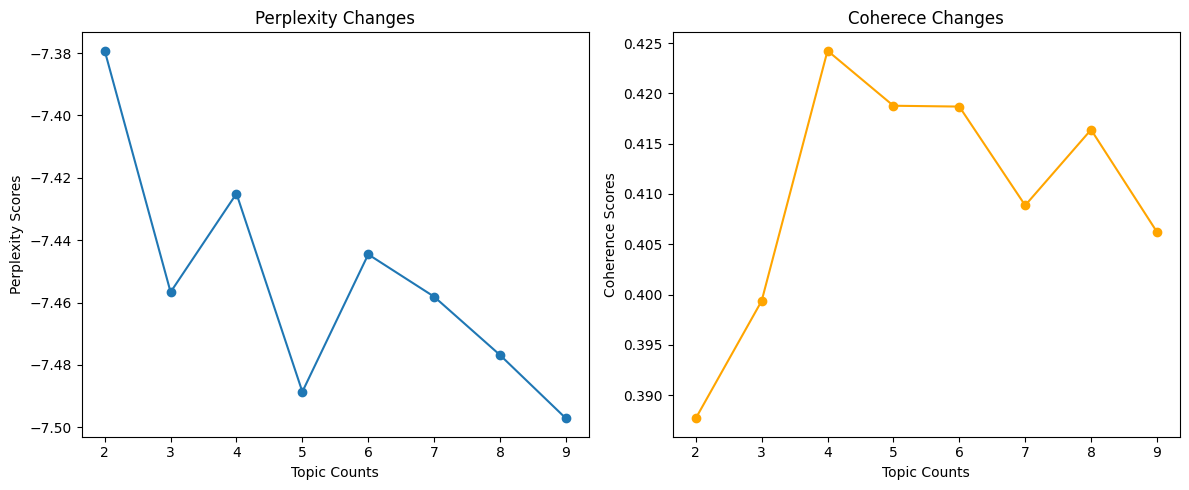

In [28]:
x = range(2,10) # 토픽 개수(2~9)
 
# 하나의 Figure 안에 여러 개의 서브 플롯(axes)을 생성
fig, ax = plt.subplots(
    1,2, # 1행 2열의 서브 플롯을 생성
    figsize = (12,5) # 전체 Figure 크기를 가로 12인치, 세로 5인치로 설정
)
 
# Perplexity 시각화
# ax[0] : 0번째 서브 플롯
# marker = 'o' : 각 데이터 포인트를 원 모양으로 표시
# linestyle = '-' : 데이터 포인트를 선으로 연결
ax[0].plot(x, perplexity_values, marker='o', linestyle = '-')
ax[0].set_xlabel('Topic Counts')
ax[0].set_ylabel('Perplexity Scores')
ax[0].set_title('Perplexity Changes')
 
# Coherence 시각화
# ax[1] : 1번째 서브 플롯
# color='orange' : 선 색상을 주황색으로 지정
ax[1].plot(x, coherence_values, marker='o', linestyle='-',color='orange')
ax[1].set_xlabel('Topic Counts')
ax[1].set_ylabel('Coherence Scores')
ax[1].set_title('Coherece Changes')
 
plt.tight_layout() # 서브 플롯 간의 레이아웃 간격을 자동으로 조정하여 겹치지 않도록 함
plt.show()
 

- perplexity, coherence 균형점 찾기 => 두 그래프를 동시에 고려해서 perplexity가 최대한 낮으면서 coherence는 높은 균형점 찾아야함
- 두 지표를 종합했을 때, 토픽 개수를 5개로 선정하는 것이 모델의 예측력과 해석 가능성 모두에서 적절한 균형을 이루는 것으로 판단되지만 추후 각 토픽별 상위단어와 원문을 고려해서 다른 토픽 개수로 테스트가 필요할 수 있다.


## 2.3 선정한 토픽 개수 Action 넘버 매칭

In [29]:
import gensim

topic_num = 5 # 생성할 토픽의 개수를 5로 설정(임의로 설정)

# LDA 모델 생성: 코퍼스 내 문서(리뷰)들을 대상으로 토픽을 추출
ldamodel = lda_model = gensim.models.ldamodel.LdaModel(
    corpus, # 각 문서를 단어 빈도수(Bag-of-Words) 형태로 표현한 코퍼스
    id2word = word_dict, # 단어 사전: 각 단어의 고유 ID와 실제 단어를 매핑하는 딕셔너리 객체(초기 할당에 활용)
    num_topics = topic_num, # 생성할 토픽의 개수(여기서는 3개)

    passes = 10,    # 기본값(1)보다 크게 설정하여 학습을 충분히 수행
                    # 전체 코퍼스를 대상으로 토픽 재할당 과정을 10번 반복, 
                    # passes 값을 높을수록 모델은 전체 데이터에 대해 여러번 학습하여 전반적인 토픽 구조를 더 안정적으로 추정할 수 있으나, 계산 비용 증가함

    iterations = 100, # 기본값(50)보다 크게 설정하여 학습을 충분히 수행
                    # 각문서(리뷰) 내에서 토픽 할당을 최적화하는 내부 알고리즘을 100번 반복 수행
                    # iterations 값이 높으면 각 문서의 토픽 할당이 더욱 세밀하게 조정
                    # 과도한 반복은 오버피팅(과적합)이나 계산 시간 증가 위험이 있음

    # passes, iterations: 두 인자를 통해 LDA 모델은 문서(리뷰)와 단어의 토픽 할당을 더욱 정교하게 조정
    random_state = 2025 # 난숫 시드 값: 결과 재현성을 위해 고정
)

In [30]:
# 각 토픽별로 가장 중요한 단어 10개를 출력
ldamodel.print_topics(num_words =10) # 각 토픽 내에서 단어와 그에 해당하는 가중치(비중)를 보여줌

# 가중치가 높을수록 => 해당 토픽에서 핵심적인 단어임을 의미
# 각각의 토픽으로 다른 행동들을 반영할 수 있음

[(0,
  '0.005*"없다" + 0.005*"주다" + 0.005*"받다" + 0.004*"퇴직금" + 0.004*"돈" + 0.004*"감사하다" + 0.003*"알다" + 0.003*"보다" + 0.003*"일용직" + 0.003*"회사"'),
 (1,
  '0.023*"받다" + 0.011*"없다" + 0.010*"근무" + 0.010*"아니다" + 0.009*"알바" + 0.008*"급여" + 0.007*"주다" + 0.006*"않다" + 0.006*"맞다" + 0.006*"사장"'),
 (2,
  '0.026*"주휴수당" + 0.018*"주" + 0.017*"받다" + 0.015*"근무" + 0.013*"시급" + 0.012*"주다" + 0.010*"없다" + 0.009*"월급" + 0.009*"계산" + 0.008*"수당"'),
 (3,
  '0.012*"없다" + 0.012*"최저임금" + 0.011*"사람" + 0.011*"받다" + 0.010*"돈" + 0.009*"임금" + 0.009*"아니다" + 0.009*"알바" + 0.008*"시급" + 0.008*"물가"'),
 (4,
  '0.028*"쿠팡" + 0.012*"없다" + 0.011*"퇴직금" + 0.011*"아니다" + 0.011*"법" + 0.010*"일용직" + 0.009*"기업" + 0.008*"주다" + 0.008*"회사" + 0.008*"계약"')]

In [31]:
# get_document_topic() : 각 문서(리뷰, BOW 벡터)에 대해 각 토픽이 문서에 기여하는 확률(비중)을 반환하는 함수
for i in range(len(ldamodel.get_document_topics(corpus))) :
  if len(ldamodel.get_document_topics(corpus)[i]) == 4:
    print(i, ldamodel.get_document_topics(corpus)[i])

# 0번 클러스터 문서의 각 리뷰에 가장 강하게 나타난 토픽들 1가지만 남겨놓고 제거한다고? 

84 [(1, 0.07048203), (2, 0.37970576), (3, 0.28298646), (4, 0.26423934)]
191 [(1, 0.31431204), (2, 0.3674085), (3, 0.1056937), (4, 0.21088178)]
292 [(0, 0.26255172), (1, 0.13723944), (3, 0.11321033), (4, 0.48579603)]
418 [(1, 0.42319593), (2, 0.31712443), (3, 0.04833425), (4, 0.20936991)]
419 [(1, 0.46657783), (2, 0.2896732), (3, 0.17996082), (4, 0.062116873)]
506 [(1, 0.015027813), (2, 0.089428395), (3, 0.46349913), (4, 0.4307735)]
566 [(0, 0.31164116), (2, 0.051543374), (3, 0.08960646), (4, 0.54366744)]


- 0번 클러스터 문서의 각 리뷰에 가장 강하게 나타난 토픽(행동) 할당
- 각 리뷰별로 토픽 분포를 확인한 후, 그 중 확률이 가장 높은 토픽을 해당 문서의 대표 행동(액션)으로 할당

In [32]:
import numpy as np

action_number_assignment = [] # 각 문서에서 가장 높은 확률을 가진 토픽 번호(액션 번호)를 저장할 리스트

for doc_topic_distribution in ldamodel.get_document_topics(corpus):
    # 각 문서(리뷰)의 토픽 분포에서 가장 높은 비중을 가진 토픽 선택

    topic_ids = [] # 문서에 할당된 토픽 번호들을 저장할 리스트
    topic_probabilities = [] # 문서에 할당된 토픽의 확률(비중)을 저장할 리스트

    # 각 (토픽-확률) 튜플 분해
    for topic_info in doc_topic_distribution:   
    
        topic_ids.append(topic_info[0])
        topic_probabilities.append(topic_info[1])

    # 각 토픽에서 가장 높은 확률을 가진 토픽의 인덱스 찾기
    max_index = np.argmax(topic_probabilities)
    
    # 가장 높은 확률을 가진 토픽의 ID 가져오기
    selected_action = topic_ids[max_index]

    # 선택 된 토픽 번호(액션 번호)를 결과 리스트에 추가
    action_number_assignment.append(selected_action)


In [33]:
len(action_number_assignment) # 0번 클러스터 문서 수와 동일해야 함

802

- 0번 클러스터 DF의 각 문서에 대한 Topic(Action Number) 매칭

In [34]:
len(df_cluster0) # 0번 클러스터 문서 수

802

In [35]:
df_cluster0["action_number"] = action_number_assignment # 0번 클러스터 문서에 대해 새 컬럼 "action_number" 추가

# SettingWithCopyWarning: 특정 행과 열을 확실하게 지정하라고 뜨는 경고

C:\Users\lgdx\AppData\Local\Temp\ipykernel_12664\3979036843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster0["action_number"] = action_number_assignment # 0번 클러스터 문서에 대해 새 컬럼 "action_number" 추가


In [36]:
df_cluster0.head() # 0번 클러스터의 상위 5개 문서 확인

,review,review_clean,tagged_review,vector,cluster,action_number
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,"[주휴수당, 관련, 문의, 댓글, 더, 답변, 드리다, 영상, 시청, 주다, 감사하...","[-0.015925527, -0.030626636, -0.015063466, 0.0...",0,2
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,"[근로, 일수, 체우, 지각, 조퇴, 상관없다, 건가, 근로계약서, 지키다, 지키다...","[-0.014826028, -0.010363224, -0.002446767, 0.0...",0,2
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,"[주, 근로, 주, 근로, 소리, 알다, 드덱, 어요, 궁금하다, 주, 주, 시급,...","[-0.06059343, -0.045346346, 0.014628361, 0.034...",0,2
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,"[선생님, 주, 하루, 바쁘다, 더하다, 경우, 잔업, 해당, 되어다, 배, 주다,...","[-0.019944737, -0.018242465, 0.002956187, 0.04...",0,2
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,"[미치다, 치킨, 받다, 부당하다, 당하다, 검색, 왕, 노무사, 영상, 접, 답답...","[-0.099948436, -0.032038588, 0.021273611, 0.00...",0,2


# 3.LDA 토픽 모델링 시각화(LDAvis 활용)
- vis : visualization

In [37]:
#!pip install pyLDAvis
# LDA 토픽 모델의 결과를 시각적으로 해석할 수 있도록 도와주는 도구

In [38]:
# pyLDAvis 라이브러리와 gensim과의 연동 모듈 임포트
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [39]:
# 준비된 LDA 모델, 코퍼스, 단어 사전을 바탕으로 시각화 데이터를 준비
prepared_data = gensimvis.prepare(
    ldamodel, # 학습된 LDA 모델
    corpus, # LDA 모델에 입력으로 사용될 코퍼스
    word_dict # LDA 모델에서 사용된 단어 사전
)

# DeprecationWarning
# 향후 IPython

In [40]:
# 준비된 시각화 데이터를 HTML 파일로 저장
pyLDAvis.save_html(
    prepared_data, 
    f'./data/ldavis_action_df_{cluster}.html' # cluster : 0번째 클러스터 DF 지정시 활용한 변수
)

In [41]:
# 경고창 무시하기! 
import warnings
warnings.filterwarnings('ignore')
 

In [42]:
# 준비된 시각화 데이터를 Jupyter 노트북 내에서 인터랙티브하게 표시
pyLDAvis.display(prepared_data)

## 하나의 토픽별로 5개가 나온다 (= Cluster)  

### 사용법 좌측 
- selected Topic : 0 => 현재 선택된 토픽번호(0번째는 전체 문서에 대한정보)
- Intertopic Distance Map(via multidimensional scaling) : 각 토픽 간의 유사도를 시각화한 그래프 => 2차원으로 차원축소 된 것이다.
    - PC1 : 첫 번째 주성분 => 토픽간의 거리를 시각적으로 표시하기 위험
    - PC2 : 두 번째 주성분 => 토픽 간의 유사도를 시각적으로 표시하기 위험
- 각각의 원 : 하나의 토픽
    - 원의 크기 : 해당 토픽이 말뭉치에서 차지하는 비율(크면 클수록 비율이 높음)
    - 원과 원 사이의 거리 : 토픽 간의 유사도(거리가 가까울수록 유사도가 높음)

- Marginal topic distribution : 각 토픽의 분포를 보여주는 그래프(각 토픽이 전체 코퍼스에 얼마나 자주 등장하는지를 백분율로 표현)

- 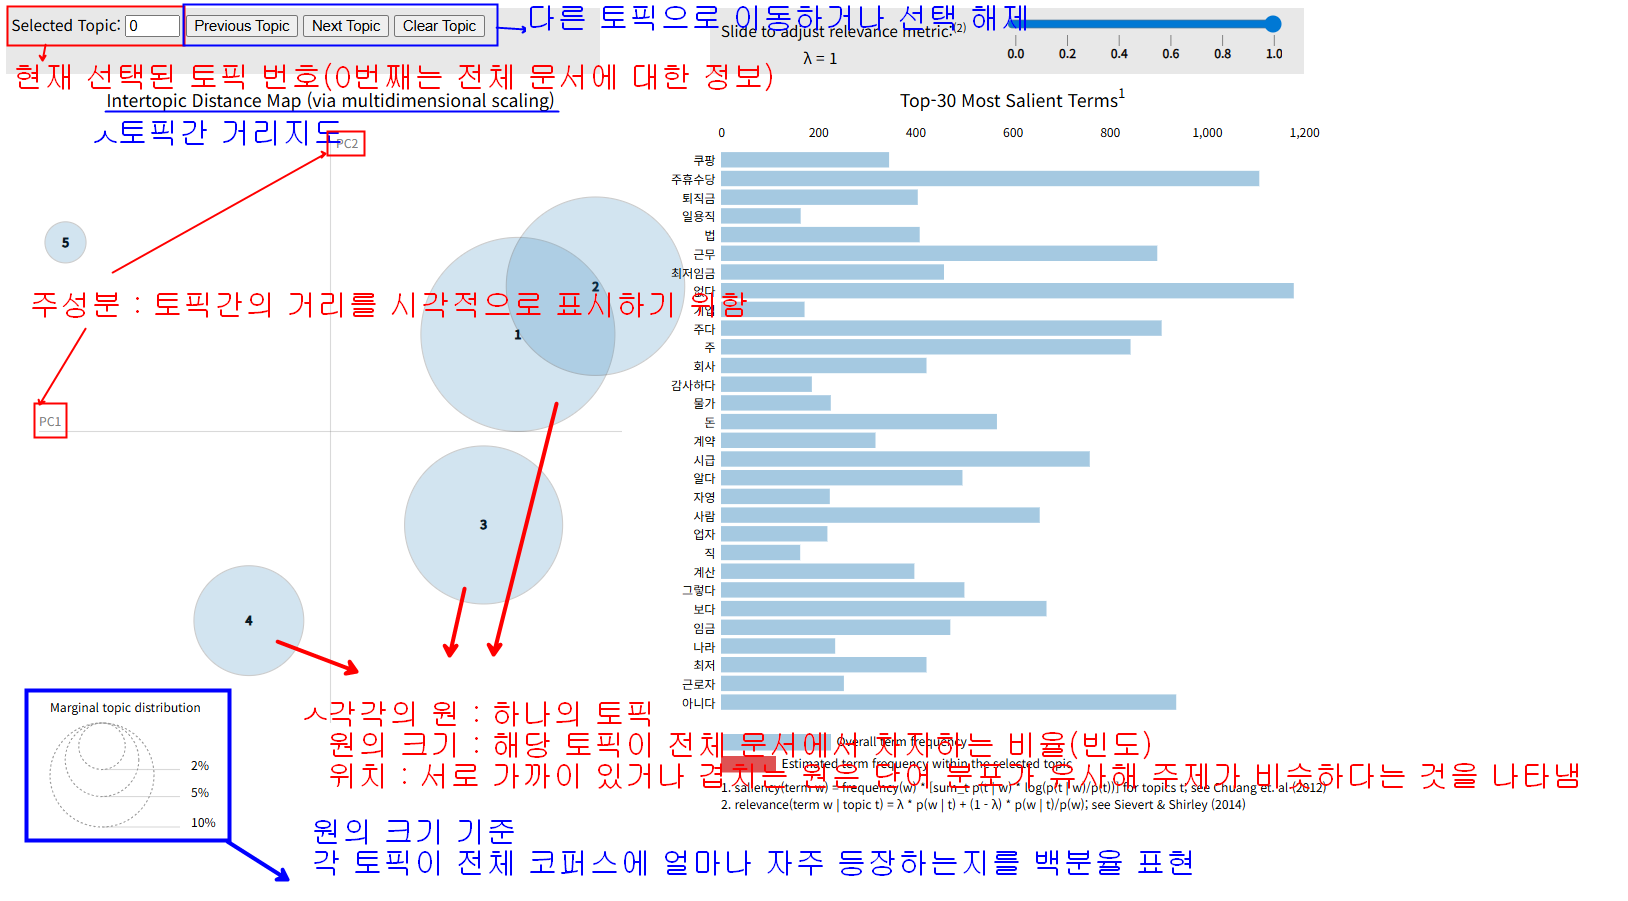

### 사용법 우측
- λ(람다)의 역할 : 
    - λ=1 인 경우 : 선택된 토픽 내의 단어가 얼마나 자주 등장하는지(토픽 내 단어확률)만을 보고 단어의 중요도 계산 
    - λ=0 인 경우 : 선택된 토픽 내에서의 빈도와 전체 문서에서의 사용 빈도를 비교한 값을 반영하여 단어의 중요도 계산
- Top-30 Most Salient Terms : 현재 선택된 토픽에서 가장 눈에 띄는 상위 30개 단어의 단어 두드러짐(Saliency) 계산 
- saliency AI관련해서는 Region Of Interest 개념임 

- multiple ^1 : 단어 두드러짐 정도: 단어가 전체 문서에서 얼마나 자주 등장하는지 여러 토픽에 걸쳐서 상대적으로 얼마나 눈에 띄는지를 함께 고려하여 단어가 얼마나 눈에 띄는지 계산, 값이 높을수록 그 단어가 여러 토픽중에서도 특별히 두드러진다는 의미

- bar plot : 전체 단어의 빈도(문서 전체에서 많이 사용된 경우는 긴 막대로 표현)
- 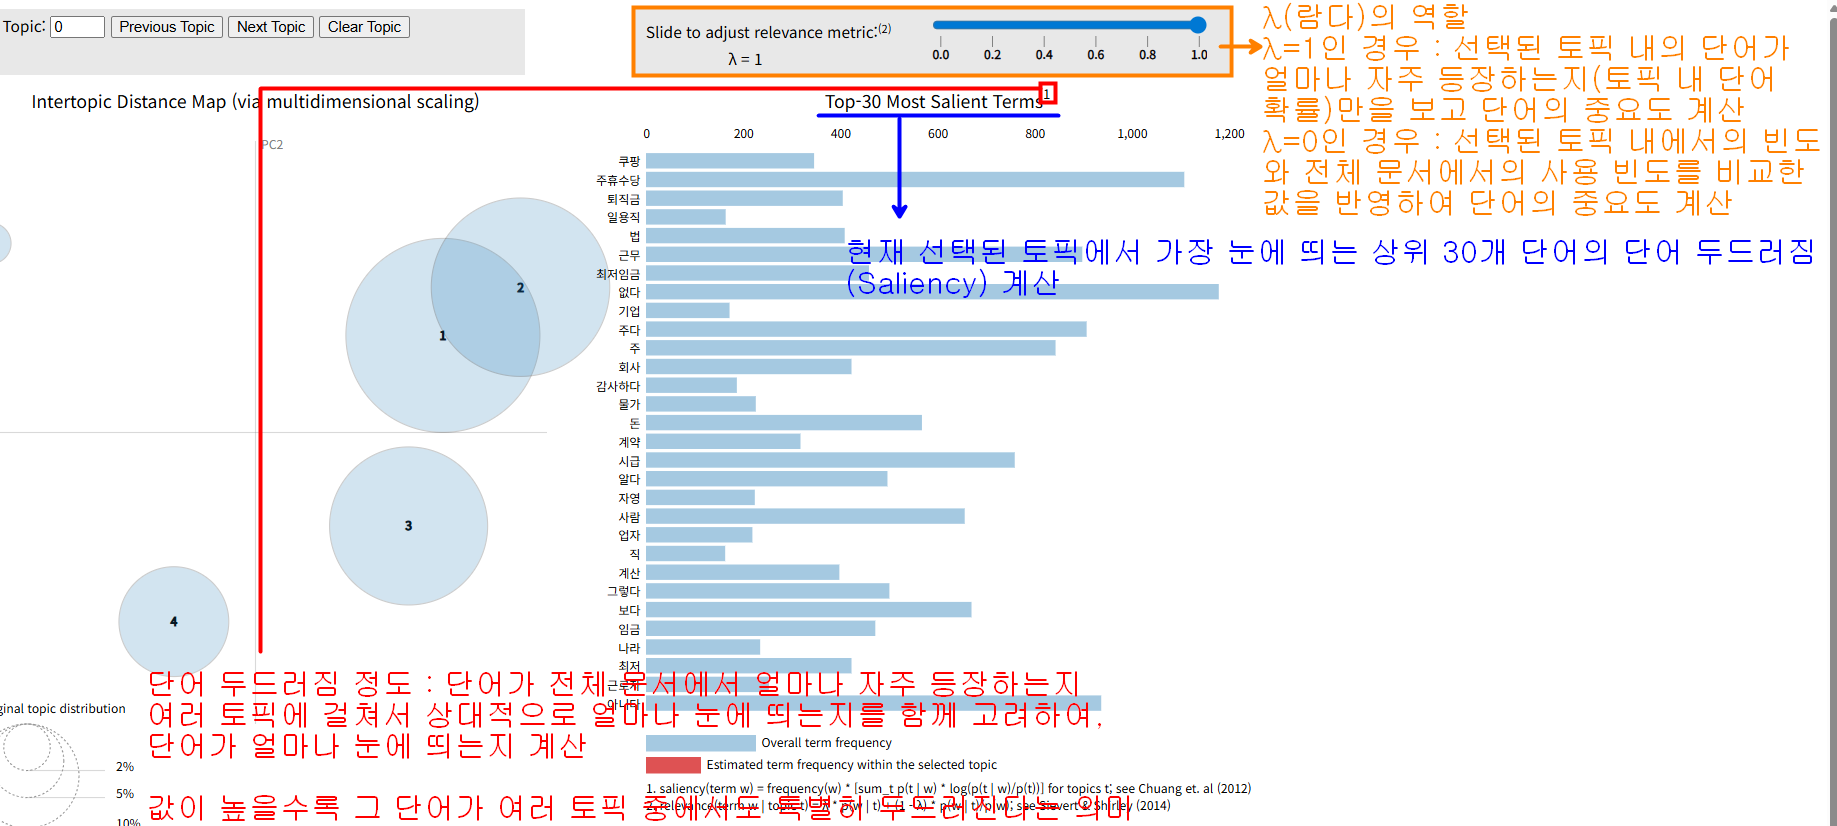



- 람다(λ) 슬라이더를 조정시 단어 순위를 다르게 볼 수 있음
    - 1에 가까울수록 단어의 해당 토픽 내의 확률(빈도)에 무게를 둔다 => 모든 문서에서 자주 등장하는 단어들이 상위에 랭크될 가능성이 높음
    - 0에 가까울수록 단어가 다른 토픽에 비해 얼마나 독특한지를 강조 => 특정 토픽에만 자주 등장하는 단어들이 상위에 랭크될 가능성이 높음
    
    - 적절하게 맞추는 것이 중요하다 (0.6) => Sievert Shirley(2014) 연구에 의하면 0.6이 가장 효과적이라고한다. 
    - 어떤 데이터셋을 사용하느냐에 따라 변경될 수 있음

    - 토픽 1에서 가장 관련성이 높은 상위 30개 단어 목록 보여줌 34.8% of tokens 
    - 전체 단어 중 약 34.8%가 이 토픽에 기여한다는 의미 
    - blue bar : 전체 코퍼스에서 각 단어가 등장한 총 빈도
    - red bar : 선택한 토픽 내에서 각 단어가 나타날 것으로 추정되는 빈도 


- 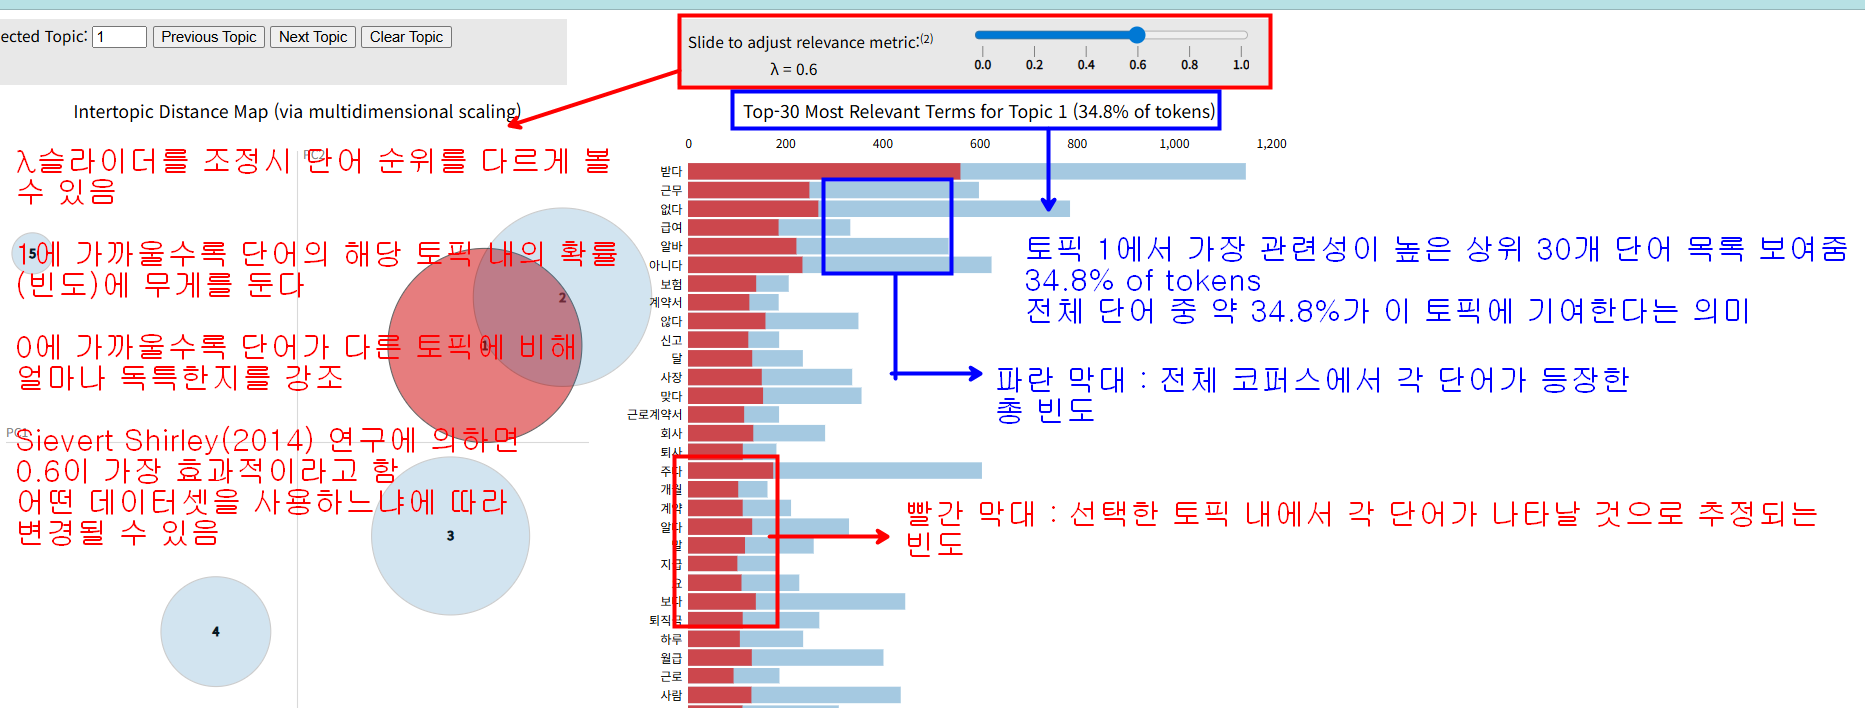

In [43]:
import sys
print(sys.executable)


c:\Python312\python.exe


### 📊 LDA 토픽 해석표 (토픽 수 = 5개 기준)
 
| 토픽 번호 | 대표 단어 예시 | 기여 비율 | 잠재적 고객 행동 (Action) |
|-----------|----------------|-----------|---------------------------|
| **1** | 받다, 근무, 없다, 급여, 월급, 계약, 퇴직금, 회사, 사장, 하루 | **34.8%** | **급여 및 근로 환경 관련 인식**<br>→ 임금 지급 여부, 계약 조건 확인, 수당·퇴직금 이슈 공유 |
| **2** | 주휴수당, 주, 근무, 시급, 받다, 계산, 수당, 알바, 연차, 알바 | **29.4%** | **알바·시급 근로자의 임금 문제**<br>→ 주휴수당 논의, 연차·수당 관심, 근무 조건 불만 제기 |
| **3** | 최저임금, 사람, 돈, 임금, 자영업, 법, 시급, 편의점, 노동자 | **23.1%** | **최저임금·노동 환경 개선 요구**<br>→ 최저임금 인상 논의, 영세 자영업자·알바의 경제적 어려움 반영 |
| **4** | 쿠팡, 기업, 퇴직금, 법, 계약, 회사, 노동자, 노동법, 배송, 리셋 | **11.1%** | **기업·플랫폼 노동 관련 이슈**<br>→ 쿠팡 등 플랫폼 기업 사례, 노동법·계약 문제, 배송직 근로 경험 |
| **5** | 암호, 계좌, 서식, 목욕, 협약, 복지사, 소득공제, 사용자 | **1.6%** | **행정·복지 제도 경험**<br>→ 복지 서비스, 세금·소득공제, 행정 절차 관련 논의 |
 
---
 
## 📝 LDA 토픽별 자연어 해석 요약
 
### 🔹 토픽 1: 급여 및 근로 환경 인식
- **핵심 키워드**: 받다, 근무, 없다, 급여, 계약, 퇴직금, 회사, 하루, 지금  
- **해석**: 직장인·아르바이트 근로자의 급여·수당 지급 여부, 근무 조건, 계약서 및 퇴직금 문제를 중심으로 한 경험 공유.  
- **특징**: 현실적인 근로 환경 문제와 불만이 주로 언급됨.  
 
---
 
### 🔹 토픽 2: 알바·시급 근로자의 임금 문제
- **핵심 키워드**: 주휴수당, 주, 시급, 알바, 수당, 연차, 받다, 계산  
- **해석**: 아르바이트 및 단시간 근무자들의 **시급 계산, 주휴수당 지급 여부, 연차 적용 문제** 등이 주요 관심사.  
- **특징**: 청년층 알바 노동 경험과 제도적 보장의 미비를 반영.  
 
---
 
### 🔹 토픽 3: 최저임금·노동 환경 개선 요구
- **핵심 키워드**: 최저임금, 사람, 돈, 자영업, 임금, 편의점, 법, 시급, 노동자  
- **해석**: **최저임금 제도, 영세 자영업자의 경영 압박, 편의점 등 서비스업의 현실**에 대한 사회적 논의.  
- **특징**: 최저임금 인상 요구와 동시에 자영업자의 어려움이 병존.  
 
---
 
### 🔹 토픽 4: 기업·플랫폼 노동 관련 이슈
- **핵심 키워드**: 쿠팡, 기업, 퇴직금, 계약, 노동법, 배송, 리셋, 노동자  
- **해석**: **대기업·플랫폼 기업(쿠팡 등)과 관련된 근로 문제, 퇴직금 미지급, 노동법 적용** 사례 중심.  
- **특징**: 배송·물류 노동자의 근로 조건과 법적 분쟁이 반영됨.  
 
---
 
### 🔹 토픽 5: 행정·복지 제도 경험
- **핵심 키워드**: 암호, 계좌, 서식, 복지사, 소득공제, 협약, 사용자, 편의  
- **해석**: **복지 서비스, 세금·소득공제, 행정 절차(서식·계좌 관리)** 등 제도적 경험 공유.  
- **특징**: 다른 토픽에 비해 규모는 작으나 복지·행정 실무 맥락이 나타남.  
 
 

# 4.LDA 분석을 위한 후작업
- LDA 모델이 생성한 토픽 번호(show_topics)와 LDAvis에서 시각화된 토픽 번호는 단순한 인덱스 차이가 아니라, 대표 단어와 기여 비율에 따라 재매핑되어야 함
- LDAvis 결과와 LDA모델의 결과를 보고 직접 매칭해야 함

In [44]:
# LDA 모델에서 전체 토픽 정보(각 토픽에 속한 단어와 가중치)를 출력
topics = ldamodel.show_topics(
    num_topics=-1, # -1: 모델 학습 토픽 5개로 했으면 5개 토픽을 모두 출력해라
    formatted = True # True: 사람이 읽기 좋은 문자열 형태로 출력
)

topics

# ldamodel의 토픽번호는 0부터 4까지 (총5개)
# LDAvis에서는 토픽 번호가 1부터 5까지로 표시됨
# LDAvis 분석 결과에 따라 변경(재매핑) 필요

[(0,
  '0.005*"없다" + 0.005*"주다" + 0.005*"받다" + 0.004*"퇴직금" + 0.004*"돈" + 0.004*"감사하다" + 0.003*"알다" + 0.003*"보다" + 0.003*"일용직" + 0.003*"회사"'),
 (1,
  '0.023*"받다" + 0.011*"없다" + 0.010*"근무" + 0.010*"아니다" + 0.009*"알바" + 0.008*"급여" + 0.007*"주다" + 0.006*"않다" + 0.006*"맞다" + 0.006*"사장"'),
 (2,
  '0.026*"주휴수당" + 0.018*"주" + 0.017*"받다" + 0.015*"근무" + 0.013*"시급" + 0.012*"주다" + 0.010*"없다" + 0.009*"월급" + 0.009*"계산" + 0.008*"수당"'),
 (3,
  '0.012*"없다" + 0.012*"최저임금" + 0.011*"사람" + 0.011*"받다" + 0.010*"돈" + 0.009*"임금" + 0.009*"아니다" + 0.009*"알바" + 0.008*"시급" + 0.008*"물가"'),
 (4,
  '0.028*"쿠팡" + 0.012*"없다" + 0.011*"퇴직금" + 0.011*"아니다" + 0.011*"법" + 0.010*"일용직" + 0.009*"기업" + 0.008*"주다" + 0.008*"회사" + 0.008*"계약"')]

In [45]:
import pyLDAvis.gensim_models

# 유사도 분석을 위한 데이터 준비=> 유사도가 높지않은경우 수정해야한다. 
prepared_data = pyLDAvis.gensim_models.prepare(ldamodel, corpus, word_dict)
prepared_data.topic_coordinates

,x,y,topics,cluster,Freq
topic,,,,,
1,0.058999,0.029282,1,1,34.781691
2,0.092757,0.050247,2,1,29.427704
3,0.044080,-0.053612,3,1,23.083730
4,-0.058035,-0.095237,4,1,11.145923
0,-0.137800,0.069319,5,1,1.560952


In [46]:
# ...existing code...
new_action_topic = []
for i in df_cluster0["action_number"]:   # 기존 action_cluster -> action_number로 교체
    if i == 1: n = 1
    elif i == 2: n = 2
    elif i == 3: n = 3
    elif i == 4: n = 4
    elif i == 0: n = 5
    else: n = int(i)  # 예외값 안전 처리
    new_action_topic.append(n)

df_cluster0["action_cluster"] = new_action_topic
# ...existing code...

In [47]:
# 기존의 action_cluster 컬럼을 재매핑된 값으로 업데이트
df_cluster0["action_cluster"] = new_action_topic

In [48]:
df_cluster0

,review,review_clean,tagged_review,vector,cluster,action_number,action_cluster
0,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,주휴수당 관련 문의 댓글은 더 이상 답변드리지 못합니다 영상 시청해 주셔서 감사합니...,"[주휴수당, 관련, 문의, 댓글, 더, 답변, 드리다, 영상, 시청, 주다, 감사하...","[-0.015925527, -0.030626636, -0.015063466, 0.0...",0,2,2
1,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,그니까 근로 일수만 체우면 지각 조퇴해도 상관없다는건가요? 근로계약서대로 시간을 안...,"[근로, 일수, 체우, 지각, 조퇴, 상관없다, 건가, 근로계약서, 지키다, 지키다...","[-0.014826028, -0.010363224, -0.002446767, 0.0...",0,2,2
2,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,주 40시간 근로해야한다고 했다가 주 15시간 근로해야한다는 뭔 소린지 못알아드덱 ...,"[주, 근로, 주, 근로, 소리, 알다, 드덱, 어요, 궁금하다, 주, 주, 시급,...","[-0.06059343, -0.045346346, 0.014628361, 0.034...",0,2,2
3,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,선생님 주5일 하루5시간근무시 바쁠때 1 2시간 일을더할경우 잔업에 해당되어1.5배...,"[선생님, 주, 하루, 바쁘다, 더하다, 경우, 잔업, 해당, 되어다, 배, 주다,...","[-0.019944737, -0.018242465, 0.002956187, 0.04...",0,2,2
4,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,미친 이러니 치킨5만원은 받아야되\n부당해고당해서 검색하다가 왕노무사님 영상을 접했...,"[미치다, 치킨, 받다, 부당하다, 당하다, 검색, 왕, 노무사, 영상, 접, 답답...","[-0.099948436, -0.032038588, 0.021273611, 0.00...",0,2,2
...,...,...,...,...,...,...,...
1058,1년미만 계약이고 면접시 3달간 수습기간 적용해서 최저 90퍼만 받기로 합의하고 일...,1년미만 계약이고 면접시 3달간 수습기간 적용해서 최저 90퍼만 받기로 합의하고 일...,"[계약, 면접, 시, 달, 수습, 기간, 적용, 최저, 퍼, 받다, 합의, 나중, ...","[-0.12046275, -0.060053736, 0.027025007, 0.039...",0,1,1
1060,주 5일 하루 9시간 정도 일합니다. 연차 월차 없어요. 퇴직금 있습니다. 직원으로...,주 5일 하루 9시간 정도 일합니다. 연차 월차 없어요. 퇴직금 있습니다. 직원으로...,"[주, 하루, 정도, 연차, 월차, 없다, 퇴직금, 직원, 들어가다, 프로, 떼다,...","[-0.09095519, -0.04673878, 0.0064137853, 0.048...",0,1,1
1061,몇일전에 직원2명이 사고를 내서 한명이 다치는 일이 생겼습니다. 그러고나서 사장이 ...,몇일전에 직원2명이 사고를 내서 한명이 다치는 일이 생겼습니다. 그러고나서 사장이 ...,"[일전, 직원, 명, 사고, 내다, 명, 다치다, 생기다, 그렇다, 사장, 계약서,...","[-0.055982698, -0.04226747, 0.008180615, 0.056...",0,1,1
1062,"1. 회사는 500명정도 규모인데, 이벤트부스였어요. 수목금토일월화 매일7시간씩 6...",1. 회사는 500명정도 규모인데 이벤트부스였어요. 수목금토일월화 매일7시간씩 6일...,"[회사, 명정, 규모, 이벤트, 부스, 목금, 토, 월화, 매일, 근로, 마지막, ...","[-0.07644216, -0.03870197, 0.0015910456, 0.034...",0,1,1


In [49]:
import pickle
df_cluster0.to_pickle(f"./data/cluster_df_{cluster}_action.pkl")